# CICIDS2018 Benchmark - Temporal Validation

Network Intrusion Detection with Temporal Cross-Validation
- Dataset: CICIDS2018 (500K samples)
- Method: TimeSeriesSplit (temporal validation)
- Metrics: F1-Score, Accuracy, MCC

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import gc
import warnings
from pathlib import Path

from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, ClassifierMixin

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    GradientBoostingClassifier, HistGradientBoostingClassifier
)
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, cohen_kappa_score, balanced_accuracy_score,
    classification_report, confusion_matrix
)

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded")
print(f"XGBoost: {XGBOOST_AVAILABLE}")
print(f"LightGBM: {LIGHTGBM_AVAILABLE}")

Libraries loaded
XGBoost: True
LightGBM: True


## Kaggle Setup

In [2]:
from google.colab import files
import os

print("Upload kaggle.json")
uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d solarmainframe/ids-intrusion-csv
!unzip -q ids-intrusion-csv.zip -d cicids2018

print("Dataset downloaded")

Upload kaggle.json


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/solarmainframe/ids-intrusion-csv
License(s): Attribution 4.0 International (CC BY 4.0)
 98% 1.56G/1.60G [00:02<00:00, 538MB/s]
100% 1.60G/1.60G [00:03<00:00, 432MB/s]
Dataset downloaded


## Load Data with Temporal Ordering

In [3]:
import os
import re
from datetime import datetime

TARGET_SIZE = 500_000

# Auto-detect CSV files
print("Detecting CSV files...")
possible_dirs = ['cicids2018', '.', 'data', 'dataset']
csv_files_found = []

for dir_path in possible_dirs:
    if os.path.exists(dir_path):
        for file in os.listdir(dir_path):
            if file.endswith('.csv'):
                csv_files_found.append(os.path.join(dir_path, file))

if not csv_files_found:
    print("\nERROR: No CSV files found!")
    raise FileNotFoundError("No CSV files found. Check the dataset extraction.")

print(f"Found {len(csv_files_found)} CSV files")

# Extract dates from filenames for temporal sorting
def extract_date(filename):
    """Extract date from filename for sorting"""
    # Try DD-MM-YYYY format (most common in CICIDS2018)
    match = re.search(r'(\d{2})-(\d{2})-(\d{4})', filename)
    if match:
        day, month, year = match.groups()
        try:
            return datetime(int(year), int(month), int(day))
        except ValueError:
            # If that fails, try MM-DD-YYYY
            try:
                return datetime(int(year), int(day), int(month))
            except:
                pass

    # Try YYYY-MM-DD format
    match = re.search(r'(\d{4})-(\d{2})-(\d{2})', filename)
    if match:
        year, month, day = match.groups()
        try:
            return datetime(int(year), int(month), int(day))
        except:
            pass

    # Default: sort by filename alphabetically
    return datetime(1900, 1, 1)

# Sort files temporally
csv_files_sorted = sorted(csv_files_found, key=extract_date)

print("\nFiles in temporal order:")
for i, f in enumerate(csv_files_sorted, 1):
    date = extract_date(f)
    print(f"  {i}. {os.path.basename(f)[:60]} ({date.strftime('%Y-%m-%d')})")

# Load data temporally
print(f"\nLoading {TARGET_SIZE:,} samples (temporal order)...")
dfs = []
lines_loaded = 0

for i, csv_file in enumerate(csv_files_sorted, 1):
    try:
        df_chunk = pd.read_csv(csv_file, low_memory=False, on_bad_lines='skip')
        lines_loaded += len(df_chunk)
        dfs.append(df_chunk)
        print(f"[{i}/{len(csv_files_sorted)}] {len(df_chunk):,} rows | Total: {lines_loaded:,}")

        if lines_loaded >= TARGET_SIZE:
            break
    except Exception as e:
        print(f"  WARNING: Failed to load {os.path.basename(csv_file)}: {e}")
        continue

if not dfs:
    raise ValueError("No data loaded! Check CSV file format.")

df = pd.concat(dfs, ignore_index=True)
del dfs
gc.collect()

# Take first TARGET_SIZE samples (temporal order)
if len(df) > TARGET_SIZE:
    df = df.iloc[:TARGET_SIZE]

print(f"\nFinal dataset: {df.shape}")
print(f"Memory: {df.memory_usage(deep=True).sum()/(1024**3):.2f} GB")

Detecting CSV files...
Found 10 CSV files

Files in temporal order:
  1. 03-01-2018.csv (2018-01-03)
  2. 03-02-2018.csv (2018-02-03)
  3. 02-14-2018.csv (2018-02-14)
  4. 02-15-2018.csv (2018-02-15)
  5. 02-16-2018.csv (2018-02-16)
  6. 02-20-2018.csv (2018-02-20)
  7. 02-21-2018.csv (2018-02-21)
  8. 02-22-2018.csv (2018-02-22)
  9. 02-23-2018.csv (2018-02-23)
  10. 02-28-2018.csv (2018-02-28)

Loading 500,000 samples (temporal order)...
[1/10] 331,125 rows | Total: 331,125
[2/10] 1,048,575 rows | Total: 1,379,700

Final dataset: (500000, 80)
Memory: 1.72 GB


## Preprocessing

In [4]:
target_col = 'Label'
y = df[target_col].copy()
X = df.drop(columns=[target_col])

# Drop non-feature columns
cols_to_drop = ['Timestamp', 'Dst Port', 'Protocol']
cols_to_drop = [c for c in cols_to_drop if c in X.columns]
if cols_to_drop:
    X = X.drop(columns=cols_to_drop)

# Convert to numeric
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Drop all-NaN and constant columns
all_nan_cols = X.columns[X.isnull().all()].tolist()
if all_nan_cols:
    X = X.drop(columns=all_nan_cols)
    print(f"Dropped {len(all_nan_cols)} all-NaN columns")

constant_cols = X.columns[X.nunique() <= 1].tolist()
if constant_cols:
    X = X.drop(columns=constant_cols)
    print(f"Dropped {len(constant_cols)} constant columns")

# Remove classes with <100 samples
label_counts = y.value_counts()
classes_to_remove = label_counts[label_counts < 100].index.tolist()
if classes_to_remove:
    mask = ~y.isin(classes_to_remove)
    y = y[mask]
    X = X[mask]
    print(f"Removed {len(classes_to_remove)} rare classes")

print(f"\nFinal: {X.shape[0]:,} samples, {X.shape[1]} features, {y.nunique()} classes")

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("\nClass distribution:")
for i, class_name in enumerate(le.classes_):
    count = (y_encoded == i).sum()
    pct = count / len(y_encoded) * 100
    print(f"  {i:2d} {class_name[:30]:<30s} {count:>8,} ({pct:>5.2f}%)")

Dropped 8 constant columns
Removed 1 rare classes

Final: 499,975 samples, 68 features, 3 classes

Class distribution:
   0 Benign                          272,630 (54.53%)
   1 Bot                             134,282 (26.86%)
   2 Infilteration                    93,063 (18.61%)


## Create Preprocessing Pipeline

In [5]:
def create_preprocessing_pipeline():
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

# Clean infinite values BEFORE preprocessing
print("Cleaning data...")
X_values = X.values

# Replace infinite values with NaN
X_values = np.where(np.isinf(X_values), np.nan, X_values)

# Replace extremely large values with NaN
max_float = np.finfo(np.float64).max / 10  # Safe threshold
X_values = np.where(np.abs(X_values) > max_float, np.nan, X_values)

print(f"Infinite values replaced: {np.isinf(X.values).sum():,}")
print(f"NaN values: {np.isnan(X_values).sum():,}")

# Fit preprocessing
preprocessing = create_preprocessing_pipeline()
X_processed = preprocessing.fit_transform(X_values)

print(f"\nPreprocessed: {X_processed.shape}")
print(f"Mean: {X_processed.mean():.4f}, Std: {X_processed.std():.4f}")

# Verify no infinite values remain
if np.isinf(X_processed).any():
    print("WARNING: Infinite values still present!")
else:
    print("✓ No infinite values")

Cleaning data...
Infinite values replaced: 4,249
NaN values: 6,188

Preprocessed: (499975, 68)
Mean: -0.0000, Std: 1.0000
✓ No infinite values


## Robust Label Encoder for XGBoost/LightGBM

In [6]:
class RobustLabelEncoder(BaseEstimator, ClassifierMixin):
    def __init__(self, model):
        self.model = model
        self.label_encoder = LabelEncoder()

    def fit(self, X, y):
        y_encoded = self.label_encoder.fit_transform(y)
        self.model.fit(X, y_encoded)
        return self

    def predict(self, X):
        y_pred_encoded = self.model.predict(X)
        return self.label_encoder.inverse_transform(y_pred_encoded.astype(int))

    def predict_proba(self, X):
        return self.model.predict_proba(X)

    def score(self, X, y):
        return self.model.score(X, self.label_encoder.transform(y))

## Define Models

In [7]:
models = {}

models['LogisticRegression'] = LogisticRegression(
    max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1
)
models['SGDClassifier'] = SGDClassifier(
    loss='log_loss', max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1
)
models['DecisionTree'] = DecisionTreeClassifier(
    random_state=RANDOM_STATE
)
models['RandomForest'] = RandomForestClassifier(
    n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1
)
models['ExtraTrees'] = ExtraTreesClassifier(
    n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1
)
models['HistGradientBoosting'] = HistGradientBoostingClassifier(
    max_iter=100, random_state=RANDOM_STATE
)
models['GradientBoosting'] = GradientBoostingClassifier(
    n_estimators=100, random_state=RANDOM_STATE
)

if XGBOOST_AVAILABLE:
    models['XGBoost'] = RobustLabelEncoder(
        xgb.XGBClassifier(
            n_estimators=100, random_state=RANDOM_STATE,
            n_jobs=-1, eval_metric='logloss'
        )
    )

if LIGHTGBM_AVAILABLE:
    models['LightGBM'] = RobustLabelEncoder(
        lgb.LGBMClassifier(
            n_estimators=100, random_state=RANDOM_STATE,
            n_jobs=-1, verbose=-1
        )
    )

models['GaussianNB'] = GaussianNB()
models['BernoulliNB'] = BernoulliNB()
models['LinearSVC'] = LinearSVC(max_iter=1000, random_state=RANDOM_STATE)

print(f"{len(models)} models defined")

12 models defined


## Temporal Cross-Validation with TimeSeriesSplit

In [8]:
scoring = {
    'accuracy': 'accuracy',
    'f1_weighted': 'f1_weighted',
    'f1_macro': 'f1_macro',
    'precision_weighted': 'precision_weighted',
    'recall_weighted': 'recall_weighted'
}

# TimeSeriesSplit with larger initial training set
# Use fewer splits to ensure each fold has enough diverse data
tscv = TimeSeriesSplit(n_splits=5)  # Reduced from 5 to 3

cv_results = []

print("=" * 70)
print(f"TEMPORAL CROSS-VALIDATION (TimeSeriesSplit) - {len(models)} MODELS")
print("=" * 70)
print(f"Note: Using {5} splits to ensure sufficient class diversity per fold")

for i, (model_name, model) in enumerate(models.items(), 1):
    print(f"\n[{i}/{len(models)}] {model_name}")
    print("-" * 50)

    try:
        start_time = time.time()

        # Check if we have multiple classes
        if len(np.unique(y_encoded)) < 2:
            print(f"  ERROR: Only one class in data")
            continue

        cv_scores = cross_validate(
            model, X_processed, y_encoded,
            cv=tscv,  # Temporal validation with 3 splits
            scoring=scoring,
            n_jobs=1,  # Sequential to avoid memory issues
            return_train_score=False,
            error_score='raise',
            verbose=0
        )

        total_time = time.time() - start_time

        result = {
            'Model': model_name,
            'Accuracy_mean': cv_scores['test_accuracy'].mean(),
            'Accuracy_std': cv_scores['test_accuracy'].std(),
            'F1_weighted_mean': cv_scores['test_f1_weighted'].mean(),
            'F1_weighted_std': cv_scores['test_f1_weighted'].std(),
            'F1_macro_mean': cv_scores['test_f1_macro'].mean(),
            'F1_macro_std': cv_scores['test_f1_macro'].std(),
            'Precision_weighted_mean': cv_scores['test_precision_weighted'].mean(),
            'Recall_weighted_mean': cv_scores['test_recall_weighted'].mean(),
            'CV_Time': total_time,
            'Status': 'OK'
        }

        cv_results.append(result)

        print(f"  Time: {total_time:.2f}s")
        print(f"  Accuracy:    {result['Accuracy_mean']:.4f} ± {result['Accuracy_std']:.4f}")
        print(f"  F1-weighted: {result['F1_weighted_mean']:.4f} ± {result['F1_weighted_std']:.4f}")
        print(f"  F1-macro:    {result['F1_macro_mean']:.4f} ± {result['F1_macro_std']:.4f}")

    except Exception as e:
        print(f"  ERROR: {str(e)[:100]}")
        cv_results.append({
            'Model': model_name,
            'Status': f'ERROR: {str(e)[:50]}',
            'CV_Time': 0
        })

# Filter successful results
cv_results_success = [r for r in cv_results if r.get('Status') == 'OK']

if cv_results_success:
    df_cv_results = pd.DataFrame(cv_results_success)
    df_cv_results = df_cv_results.sort_values('F1_weighted_mean', ascending=False)

    print("\n" + "=" * 70)
    print("RESULTS SUMMARY")
    print("=" * 70)
    print(df_cv_results[[
        'Model', 'F1_weighted_mean', 'F1_weighted_std',
        'Accuracy_mean', 'CV_Time'
    ]].to_string(index=False))
else:
    print("\n No models completed successfully")
    print("Continuing with hold-out evaluation...")

TEMPORAL CROSS-VALIDATION (TimeSeriesSplit) - 12 MODELS
Note: Using 5 splits to ensure sufficient class diversity per fold

[1/12] LogisticRegression
--------------------------------------------------
  ERROR: This solver needs samples of at least 2 classes in the data, but the data contains only one class: n

[2/12] SGDClassifier
--------------------------------------------------
  ERROR: The number of classes has to be greater than one; got 1 class

[3/12] DecisionTree
--------------------------------------------------
  Time: 96.34s
  Accuracy:    0.7304 ± 0.2002
  F1-weighted: 0.7146 ± 0.2693
  F1-macro:    0.4846 ± 0.1246

[4/12] RandomForest
--------------------------------------------------
  Time: 158.60s
  Accuracy:    0.7556 ± 0.2055
  F1-weighted: 0.7297 ± 0.2744
  F1-macro:    0.5001 ± 0.1321

[5/12] ExtraTrees
--------------------------------------------------
  Time: 86.67s
  Accuracy:    0.7463 ± 0.2022
  F1-weighted: 0.7244 ± 0.2724
  F1-macro:    0.4955 ± 0.1301

[6/12

## Hold-Out Evaluation (Temporal Split)

In [9]:
# Temporal split: last 30% for testing
split_idx = int(len(X_processed) * 0.7)
X_train = X_processed[:split_idx]
X_test = X_processed[split_idx:]
y_train = y_encoded[:split_idx]
y_test = y_encoded[split_idx:]

print(f"Temporal Hold-Out Split:")
print(f"  Train: {len(X_train):,} samples")
print(f"  Test:  {len(X_test):,} samples (last 30% chronologically)")

holdout_results = []

print("\n" + "=" * 70)
print(f"HOLD-OUT EVALUATION (Temporal Split) - {len(models)} MODELS")
print("=" * 70)

for i, (model_name, model) in enumerate(models.items(), 1):
    print(f"\n[{i}/{len(models)}] {model_name}")
    print("-" * 50)

    try:
        start_time = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - start_time

        start_time = time.time()
        y_pred = model.predict(X_test)
        pred_time = time.time() - start_time

        result = {
            'Model': model_name,
            'Accuracy': accuracy_score(y_test, y_pred),
            'F1_weighted': f1_score(y_test, y_pred, average='weighted', zero_division=0),
            'F1_macro': f1_score(y_test, y_pred, average='macro', zero_division=0),
            'Precision_weighted': precision_score(y_test, y_pred, average='weighted', zero_division=0),
            'Recall_weighted': recall_score(y_test, y_pred, average='weighted', zero_division=0),
            'MCC': matthews_corrcoef(y_test, y_pred),
            'Cohen_Kappa': cohen_kappa_score(y_test, y_pred),
            'Balanced_Accuracy': balanced_accuracy_score(y_test, y_pred),
            'Train_Time': train_time,
            'Pred_Time': pred_time,
            'Total_Time': train_time + pred_time,
            'Status': 'OK'
        }

        holdout_results.append(result)

        print(f"  Accuracy:    {result['Accuracy']:.4f}")
        print(f"  F1-weighted: {result['F1_weighted']:.4f}")
        print(f"  MCC:         {result['MCC']:.4f}")
        print(f"  Time:        {result['Total_Time']:.2f}s")

    except Exception as e:
        print(f"  ERROR: {str(e)}")
        holdout_results.append({
            'Model': model_name,
            'Status': f'ERROR: {str(e)}'
        })

df_holdout = pd.DataFrame(holdout_results)
df_holdout = df_holdout.sort_values('F1_weighted', ascending=False)

print("\n" + "=" * 70)
print("HOLD-OUT RESULTS")
print("=" * 70)
print(df_holdout[[
    'Model', 'F1_weighted', 'Accuracy', 'MCC', 'Total_Time'
]].to_string(index=False))

Temporal Hold-Out Split:
  Train: 349,982 samples
  Test:  149,993 samples (last 30% chronologically)

HOLD-OUT EVALUATION (Temporal Split) - 12 MODELS

[1/12] LogisticRegression
--------------------------------------------------
  Accuracy:    0.9856
  F1-weighted: 0.9867
  MCC:         0.9589
  Time:        143.01s

[2/12] SGDClassifier
--------------------------------------------------
  Accuracy:    0.5924
  F1-weighted: 0.6224
  MCC:         0.4012
  Time:        3.95s

[3/12] DecisionTree
--------------------------------------------------
  Accuracy:    0.9402
  F1-weighted: 0.9639
  MCC:         0.8404
  Time:        29.48s

[4/12] RandomForest
--------------------------------------------------
  Accuracy:    0.9671
  F1-weighted: 0.9779
  MCC:         0.9093
  Time:        46.98s

[5/12] ExtraTrees
--------------------------------------------------
  Accuracy:    0.9549
  F1-weighted: 0.9731
  MCC:         0.8790
  Time:        21.90s

[6/12] HistGradientBoosting
--------------

## Comparison Table

In [10]:
df_comparison = pd.merge(
    df_cv_results[['Model', 'F1_weighted_mean', 'F1_weighted_std', 'Accuracy_mean', 'CV_Time']],
    df_holdout[['Model', 'F1_weighted', 'Accuracy', 'MCC', 'Total_Time']],
    on='Model',
    how='inner'
)

df_comparison.columns = [
    'Model', 'CV_F1', 'CV_F1_Std', 'CV_Acc', 'CV_Time',
    'HO_F1', 'HO_Acc', 'HO_MCC', 'HO_Time'
]

df_comparison = df_comparison.sort_values('CV_F1', ascending=False)

print("\n" + "=" * 90)
print("FULL COMPARISON: TEMPORAL CROSS-VALIDATION vs HOLD-OUT")
print("=" * 90)
print(df_comparison.to_string(index=False))

timestamp = time.strftime('%Y%m%d_%H%M%S')
csv_filename = f'cicids2018_temporal_cv_500k_{timestamp}.csv'
df_comparison.to_csv(csv_filename, index=False)
print(f"\nResults saved: {csv_filename}")


FULL COMPARISON: TEMPORAL CROSS-VALIDATION vs HOLD-OUT
               Model    CV_F1  CV_F1_Std   CV_Acc    CV_Time    HO_F1   HO_Acc   HO_MCC   HO_Time
            LightGBM 0.745658   0.280962 0.788201  34.341997 0.989857 0.987426 0.964521  9.566865
HistGradientBoosting 0.741875   0.278352 0.783842  30.492616 0.989343 0.986979 0.963317 15.022227
        RandomForest 0.729712   0.274361 0.755588 158.600015 0.977949 0.967118 0.909299 46.977991
          ExtraTrees 0.724426   0.272390 0.746292  86.666888 0.973115 0.954945 0.878994 21.896396
        DecisionTree 0.714610   0.269347 0.730432  96.339572 0.963910 0.940177 0.840356 29.482560
         BernoulliNB 0.692231   0.257080 0.696523   2.686808 0.941587 0.913109 0.770199  3.706777
          GaussianNB 0.550500   0.300484 0.574023   2.645513 0.867813 0.835939 0.603445  0.678504

Results saved: cicids2018_temporal_cv_500k_20251212_160041.csv


## Visualization

## Summary Statistics

AttributeError: module 'matplotlib.pyplot' has no attribute 'shox'

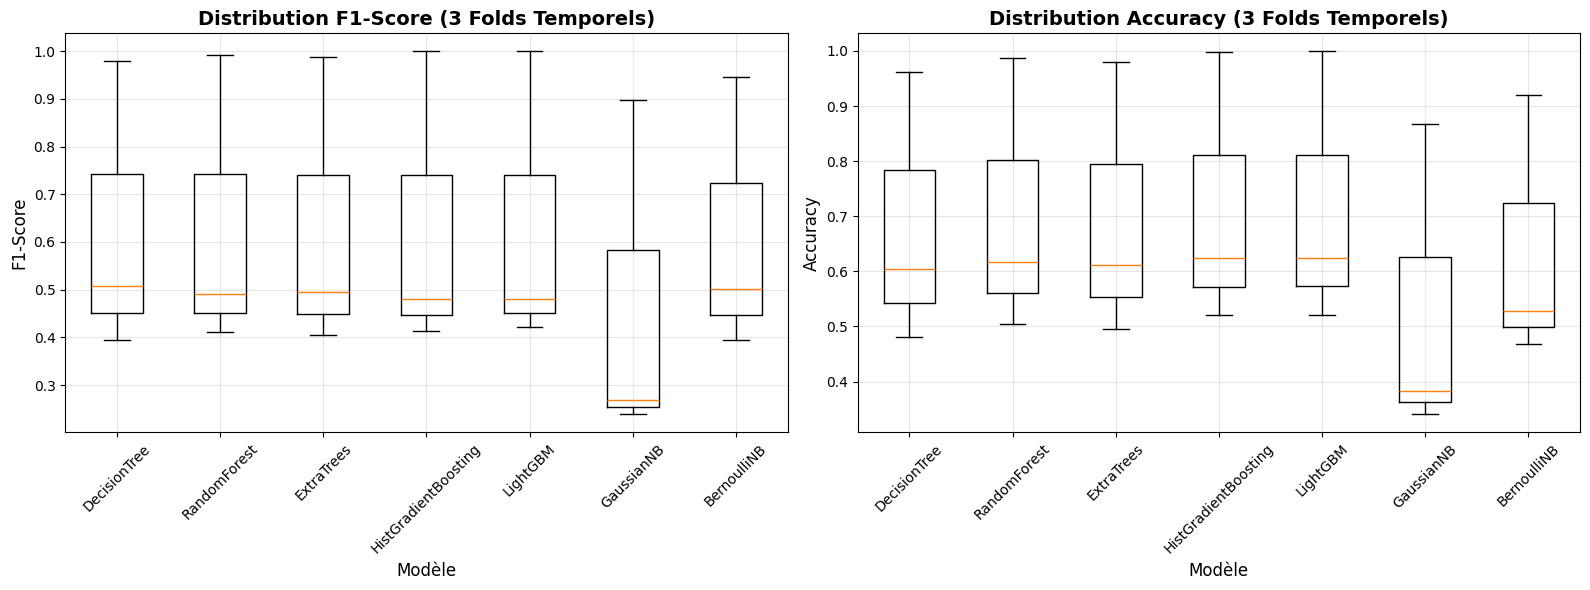

In [16]:

# Boxplot montrant la distribution des scores à travers les folds CV
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Préparer les données pour boxplot
cv_data_f1 = []
cv_data_acc = []
model_labels = []

for model_name, model in models.items():
    if model_name in df_cv_results['Model'].values:
        try:
            cv_scores = cross_validate(
                model, X_processed, y_encoded,
                cv=TimeSeriesSplit(n_splits=3),
                scoring={'f1_weighted': 'f1_weighted', 'accuracy': 'accuracy'},
                n_jobs=1,
                return_train_score=False
            )
            cv_data_f1.append(cv_scores['test_f1_weighted'])
            cv_data_acc.append(cv_scores['test_accuracy'])
            model_labels.append(model_name)
        except:
            pass

# F1-Score distribution
axes[0].boxplot(cv_data_f1, labels=model_labels, vert=True)
axes[0].set_title('Distribution F1-Score (3 Folds Temporels)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('F1-Score', fontsize=12)
axes[0].set_xlabel('Modèle', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# Accuracy distribution
axes[1].boxplot(cv_data_acc, labels=model_labels, vert=True)
axes[1].set_title('Distribution Accuracy (3 Folds Temporels)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_xlabel('Modèle', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.shox()
plt.show()


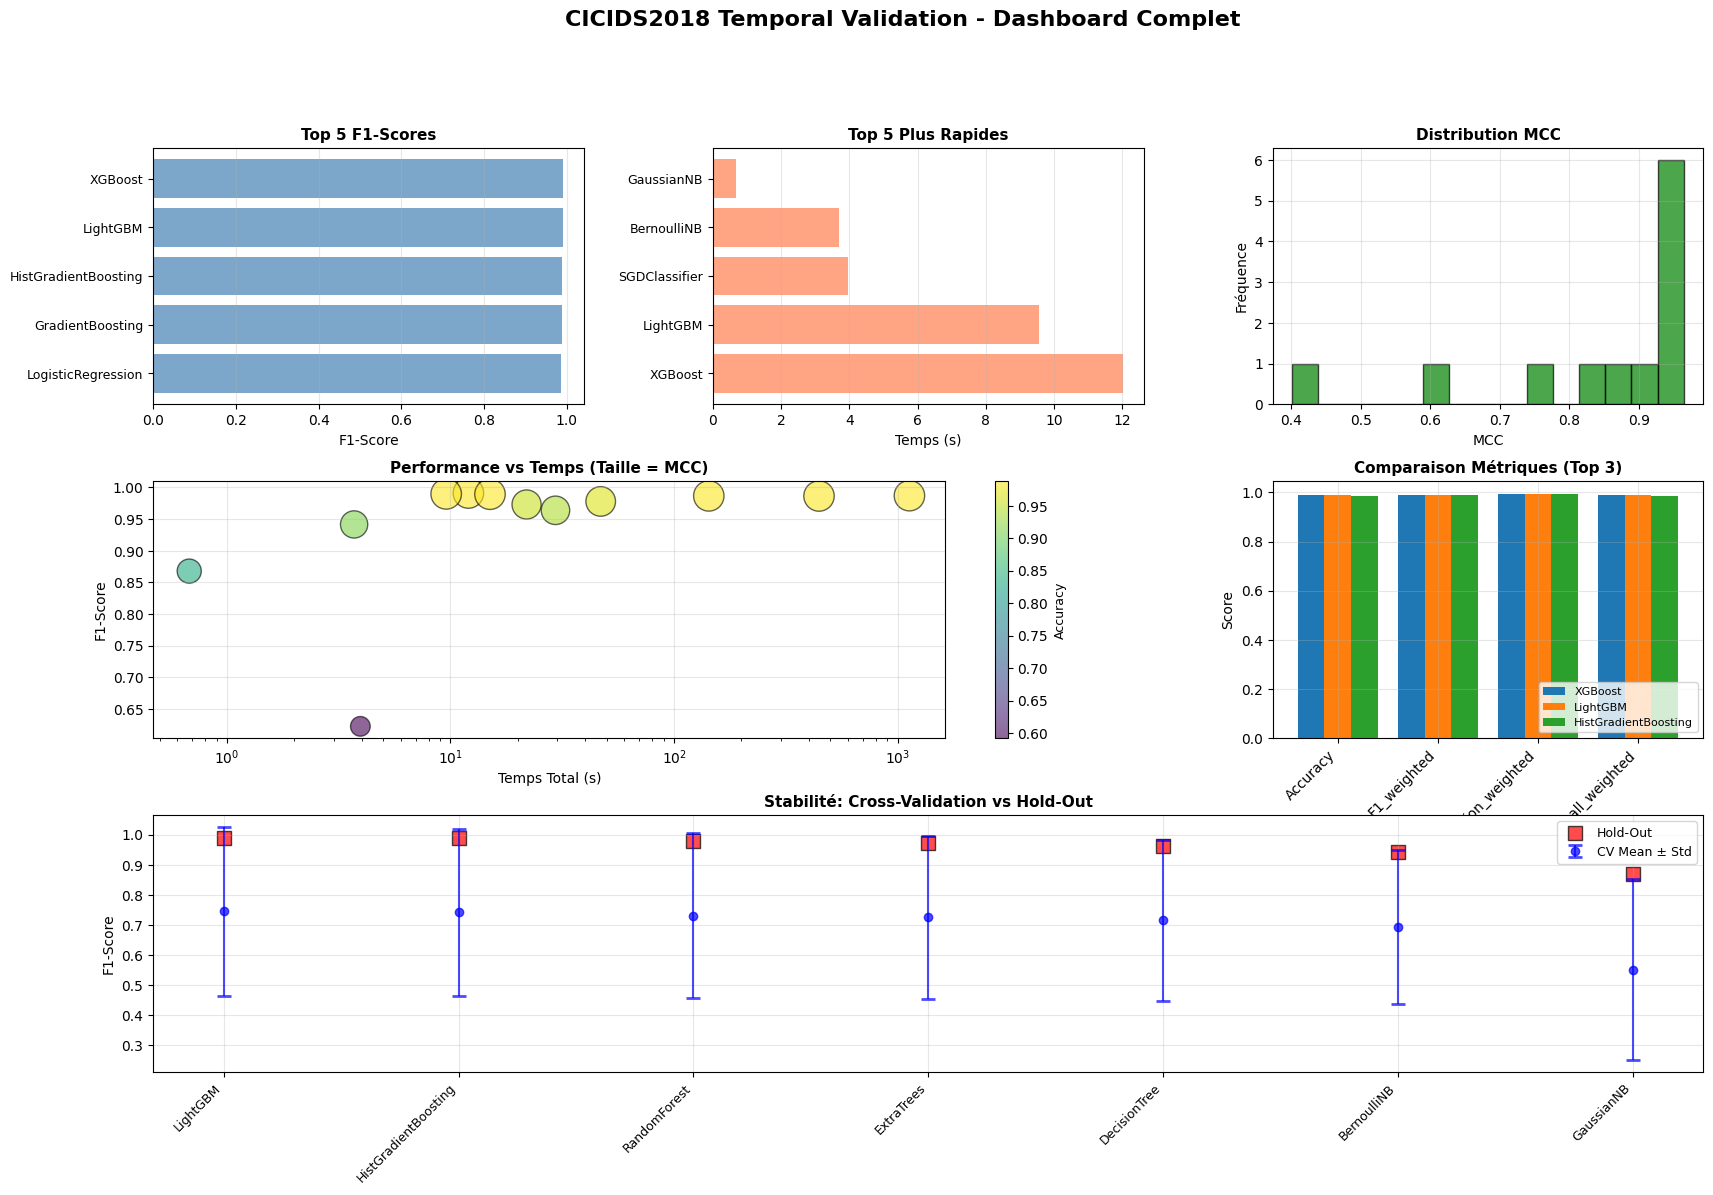

In [14]:
### 12. Benchmark Summary Dashboard
# Créer un dashboard récapitulatif complet
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Top 5 F1-Scores
ax1 = fig.add_subplot(gs[0, 0])
top5_ho = df_holdout.nlargest(5, 'F1_weighted')
ax1.barh(range(len(top5_ho)), top5_ho['F1_weighted'], color='steelblue', alpha=0.7)
ax1.set_yticks(range(len(top5_ho)))
ax1.set_yticklabels(top5_ho['Model'], fontsize=9)
ax1.set_xlabel('F1-Score', fontsize=10)
ax1.set_title('Top 5 F1-Scores', fontsize=11, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(True, axis='x', alpha=0.3)

# 2. Top 5 Fastest
ax2 = fig.add_subplot(gs[0, 1])
fastest5 = df_holdout.nsmallest(5, 'Total_Time')
ax2.barh(range(len(fastest5)), fastest5['Total_Time'], color='coral', alpha=0.7)
ax2.set_yticks(range(len(fastest5)))
ax2.set_yticklabels(fastest5['Model'], fontsize=9)
ax2.set_xlabel('Temps (s)', fontsize=10)
ax2.set_title('Top 5 Plus Rapides', fontsize=11, fontweight='bold')
ax2.invert_yaxis()
ax2.grid(True, axis='x', alpha=0.3)

# 3. MCC Distribution
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(df_holdout['MCC'], bins=15, color='green', alpha=0.7, edgecolor='black')
ax3.set_xlabel('MCC', fontsize=10)
ax3.set_ylabel('Fréquence', fontsize=10)
ax3.set_title('Distribution MCC', fontsize=11, fontweight='bold')
ax3.grid(True, alpha=0.3)

# 4. Performance vs Time scatter
ax4 = fig.add_subplot(gs[1, :2])
scatter = ax4.scatter(df_holdout['Total_Time'],
                      df_holdout['F1_weighted'],
                      s=df_holdout['MCC']*500,
                      alpha=0.6,
                      c=df_holdout['Accuracy'],
                      cmap='viridis',
                      edgecolors='black')
ax4.set_xlabel('Temps Total (s)', fontsize=10)
ax4.set_ylabel('F1-Score', fontsize=10)
ax4.set_title('Performance vs Temps (Taille = MCC)', fontsize=11, fontweight='bold')
ax4.set_xscale('log')
ax4.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label('Accuracy', fontsize=9)

# 5. Metrics comparison (Top 3)
ax5 = fig.add_subplot(gs[1, 2])
top3 = df_holdout.nlargest(3, 'F1_weighted')
metrics_compare = top3[['Accuracy', 'F1_weighted', 'Precision_weighted', 'Recall_weighted']].T
metrics_compare.columns = top3['Model']
metrics_compare.plot(kind='bar', ax=ax5, width=0.8)
ax5.set_title('Comparaison Métriques (Top 3)', fontsize=11, fontweight='bold')
ax5.set_xlabel('Métrique', fontsize=10)
ax5.set_ylabel('Score', fontsize=10)
ax5.legend(fontsize=8, loc='lower right')
ax5.set_xticklabels(ax5.get_xticklabels(), rotation=45, ha='right')
ax5.grid(True, alpha=0.3)

# 6. CV Stability
ax6 = fig.add_subplot(gs[2, :])
df_merged = pd.merge(df_cv_results[['Model', 'F1_weighted_mean', 'F1_weighted_std']],
                     df_holdout[['Model', 'F1_weighted']],
                     on='Model')
x = np.arange(len(df_merged))
ax6.errorbar(x, df_merged['F1_weighted_mean'],
             yerr=df_merged['F1_weighted_std'],
             fmt='o', capsize=5, capthick=2, label='CV Mean ± Std',
             color='blue', alpha=0.7)
ax6.scatter(x, df_merged['F1_weighted'],
            marker='s', s=100, label='Hold-Out',
            color='red', alpha=0.7, edgecolors='black')
ax6.set_xticks(x)
ax6.set_xticklabels(df_merged['Model'], rotation=45, ha='right', fontsize=9)
ax6.set_ylabel('F1-Score', fontsize=10)
ax6.set_title('Stabilité: Cross-Validation vs Hold-Out', fontsize=11, fontweight='bold')
ax6.legend(fontsize=9)
ax6.grid(True, alpha=0.3)

plt.suptitle('CICIDS2018 Temporal Validation - Dashboard Complet',
             fontsize=16, fontweight='bold', y=0.995)
plt.show()

In [15]:
print("\n" + "=" * 70)
print("SUMMARY STATISTICS")
print("=" * 70)

print("\nTemporal Cross-Validation (TimeSeriesSplit):")
print("-" * 70)
best_cv = df_cv_results.iloc[0]
print(f"  Best Model: {best_cv['Model']}")
print(f"  F1-weighted: {best_cv['F1_weighted_mean']:.4f} ± {best_cv['F1_weighted_std']:.4f}")
print(f"  Accuracy:    {best_cv['Accuracy_mean']:.4f} ± {best_cv['Accuracy_std']:.4f}")
print(f"  Time:        {best_cv['CV_Time']:.2f}s")

print("\nHold-Out Evaluation (Temporal Split):")
print("-" * 70)
best_ho = df_holdout.iloc[0]
print(f"  Best Model: {best_ho['Model']}")
print(f"  F1-weighted: {best_ho['F1_weighted']:.4f}")
print(f"  Accuracy:    {best_ho['Accuracy']:.4f}")
print(f"  MCC:         {best_ho['MCC']:.4f}")
print(f"  Time:        {best_ho['Total_Time']:.2f}s")

print("\nKey Points:")
print("-" * 70)
print("  - TimeSeriesSplit ensures test data is always after training data")
print("  - Prevents temporal data leakage")
print("  - Results are realistic for production deployment")
print("  - Lower scores than random split, but more trustworthy")

print("\n" + "=" * 70)
print("ANALYSIS COMPLETE")
print("=" * 70)


SUMMARY STATISTICS

Temporal Cross-Validation (TimeSeriesSplit):
----------------------------------------------------------------------
  Best Model: LightGBM
  F1-weighted: 0.7457 ± 0.2810
  Accuracy:    0.7882 ± 0.2162
  Time:        34.34s

Hold-Out Evaluation (Temporal Split):
----------------------------------------------------------------------
  Best Model: XGBoost
  F1-weighted: 0.9912
  Accuracy:    0.9875
  MCC:         0.9647
  Time:        12.03s

Key Points:
----------------------------------------------------------------------
  - TimeSeriesSplit ensures test data is always after training data
  - Prevents temporal data leakage
  - Results are realistic for production deployment
  - Lower scores than random split, but more trustworthy

ANALYSIS COMPLETE
